# 🌾 Can AI Predict Irrigation?

Welcome! Today we are going to build a tiny machine learning model that tries to predict how much irrigation happened on a farm.

You do **not** need to know coding or machine learning already. The notebook is written like a recipe:

1. Run each code cell from top to bottom.
2. Read the short notes.
3. Change the values in the boxes/sliders when asked.
4. See how the model changes.

## The story

A farmer has a center pivot irrigation system. The field gets different weather each day: hot days, windy days, rainy days, dry days.

We will ask:

> Can a computer learn a pattern between weather and irrigation?

At the end, we will enter **today's weather** and ask the model to guess today's irrigation.

## 🧠 What is machine learning?

Machine learning is not magic. It is pattern finding.

Instead of writing a rule like:

> If it is hot and dry, irrigate more.

we give the computer examples like:

| Weather | Irrigation |
|---|---:|
| Hot and dry | More water |
| Cool and rainy | Less water |

Then the model tries to learn the pattern.

In this notebook, we will try two models:

1. **Linear Regression**: a simple formula.
2. **Small Neural Network**: a tiny AI model made of connected neurons.

## ▶️ Step 1: Load our tools

Run the cell below. It loads the Python tools we need.

Do not worry about understanding every line. Think of this as taking tools out of a toolbox.

In [25]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output, Markdown
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False

try:
    import tensorflow as tf
    TF_AVAILABLE = True
    tf.random.set_seed(42)
except Exception:
    TF_AVAILABLE = False

np.random.seed(42)
random.seed(42)

print("✅ Tools loaded!")
print(f"Interactive widgets available: {WIDGETS_AVAILABLE}")
print(f"TensorFlow available: {TF_AVAILABLE}")

✅ Tools loaded!
Interactive widgets available: True
TensorFlow available: True


## 🌦️ Step 2: Load the farm weather + irrigation data

The dataset has one row per day. Each row includes:

- A few **weather clues** about that day: temperature, humidity, wind, and rain
- A target column called `irrigation_amount` (what we want to predict)

To make this activity fun, we will also **invent some silly clues** that have *nothing* to do with irrigation, like the farmer's lucky number and how many naps the barn cat took. 🐱

Later you will get to choose which clues the model is allowed to use. Part of the challenge is figuring out which clues are **helpful** and which are just **noise**.

`irrigation_amount` is a practice target. It is a simple estimate of how much water the field needed that day (water lost to the weather minus the rain that fell). It is not real farmer irrigation, just a good way to test our models.

In [26]:
import json
import numpy as np
import pandas as pd

df = pd.read_csv("data/model_dataset.csv")

target_col = "irrigation_amount"

# -----------------------------------------------------------
# The GOOD clues: real weather measurements about each day.
# These actually have something to do with irrigation.
# We keep it small: 4 simple weather clues + 1 "moving average"
# (the average temperature over the last 3 days).
# -----------------------------------------------------------
GOOD_FEATURES = [
    "max_temp_f",        # how hot it got
    "mean_humidity_pct", # how humid the air was
    "avg_wind_mph",      # how windy it was
    "precip_in",         # how much it rained
    "temp_3day_avg_f",   # average temperature over the last 3 days (a "moving average")
]

# -----------------------------------------------------------
# The JUNK clues: silly made-up numbers that have NOTHING
# to do with irrigation. We add them on purpose so we can see
# what happens when a model uses bad clues. 🎲🐱
# -----------------------------------------------------------
rng = np.random.default_rng(7)
n = len(df)
df["lucky_number"]       = rng.integers(1, 100, n)   # the farmer's lucky number that day
df["barn_cat_naps"]      = rng.integers(0, 12, n)    # how many naps the barn cat took
df["dice_roll"]          = rng.integers(1, 7, n)     # a roll of a six-sided dice
df["tractor_color_code"] = rng.integers(1, 6, n)     # a code for the tractor's color
df["songs_on_radio"]     = rng.integers(0, 40, n)    # songs played on the tractor radio

JUNK_FEATURES = [
    "lucky_number",
    "barn_cat_naps",
    "dice_roll",
    "tractor_color_code",
    "songs_on_radio",
]

# All the clues a student is allowed to pick from later.
ALL_FEATURES = GOOD_FEATURES + JUNK_FEATURES

# IMPORTANT: the FIRST model on purpose starts with only the junk clues,
# so it does a bad job. Your challenge later is to do better!
DEFAULT_FEATURES = list(JUNK_FEATURES)

print("Target:", target_col)
print("Rows:", len(df))
print("Good clues:", GOOD_FEATURES)
print("Junk clues:", JUNK_FEATURES)

df.head()

Target: irrigation_amount
Target type: proxy_et0_minus_precip
Rows: 2192


,date,target_type,irrigation_amount,irrigation_unit,estimated_irrigation_need_in,max_temp_f,min_temp_f,mean_temp_f,mean_humidity_pct,precip_in,...,temp_3day_avg_f,temp_5day_avg_f,precip_3day_sum_in,precip_5day_sum_in,wind_3day_avg_mph,days_since_rain,previous_irrigation_amount,days_since_irrigation,day_of_year,month
0,2020-06-14,proxy_et0_minus_precip,0.000,proxy_inches,0.000,57.3,40.6,48.9,73.417,0.244,...,48.9000,48.9000,0.244,0.244,5.6380,0,0.000,1,166,6
1,2020-06-15,proxy_et0_minus_precip,0.000,proxy_inches,0.000,54.6,45.5,50.4,82.125,0.386,...,49.6500,49.6500,0.630,0.630,4.8400,0,0.000,2,167,6
2,2020-06-16,proxy_et0_minus_precip,0.000,proxy_inches,0.000,57.2,45.8,49.7,78.792,0.449,...,49.6667,49.6667,1.079,1.079,4.3960,0,0.000,3,168,6
3,2020-06-17,proxy_et0_minus_precip,0.131,proxy_inches,0.131,64.8,43.0,54.7,66.917,0.000,...,51.6000,50.9250,0.835,1.079,3.7193,1,0.000,0,169,6
4,2020-06-18,proxy_et0_minus_precip,0.162,proxy_inches,0.162,69.3,47.0,58.8,65.083,0.012,...,54.4000,52.5000,0.461,1.091,3.2027,0,0.131,0,170,6


## 🔍 Step 3: What do the columns mean?

A **variable** is a column in the data.

Some variables are inputs. These are clues the model can use.

The target is what the model tries to guess.

Our target is:

```text
irrigation_amount
```

That means the model is trying to answer:

> How much irrigation happened that day?

In [27]:
variable_guide = pd.DataFrame([
    ["max_temp_f", "Highest temperature that day", "✅ Good clue: hotter days may need more water"],
    ["mean_humidity_pct", "Average humidity", "✅ Good clue: dry air can increase water loss"],
    ["avg_wind_mph", "Average wind speed", "✅ Good clue: wind can dry out the field"],
    ["precip_in", "Rain that day", "✅ Good clue: rain means less irrigation needed"],
    ["temp_3day_avg_f", "Average temperature over the last 3 days", "✅ Good clue: captures recent heat (a moving average)"],
    ["lucky_number", "The farmer's lucky number", "❌ Junk clue: has nothing to do with water!"],
    ["barn_cat_naps", "Naps the barn cat took", "❌ Junk clue: the cat does not control the weather"],
    ["dice_roll", "A roll of a dice", "❌ Junk clue: pure random luck"],
    ["tractor_color_code", "A code for the tractor's color", "❌ Junk clue: paint does not water crops"],
    ["songs_on_radio", "Songs played on the radio", "❌ Junk clue: music is not irrigation"],
    ["irrigation_amount", "Irrigation amount", "🎯 This is what we predict"],
], columns=["Variable", "What it measures", "Helpful or junk?"])

variable_guide

,Variable,What it measures,Why it matters
0,max_temp_f,Highest temperature that day,Hotter days may need more water
1,mean_humidity_pct,Average humidity,Dry air can increase water loss
2,precip_in,Rain that day,Rain may reduce irrigation
3,avg_wind_mph,Average wind speed,Wind can increase evaporation
4,et0_in,Reference evapotranspiration,Estimate of atmospheric water demand
5,temp_3day_avg_f,Average temperature over 3 days,Captures recent heat
6,precip_3day_sum_in,Rain over 3 days,Captures recent rainfall
7,previous_irrigation_amount,Yesterday's irrigation,Farmers may adjust based on recent irrigation
8,days_since_irrigation,Days since last irrigation,Helps model timing
9,irrigation_amount,Irrigation amount,This is what we predict


## 📊 Step 4: Explore the data

Let's plot the weather and irrigation over time.

Question to ask yourself:

> Do hot/dry periods seem to line up with more irrigation?

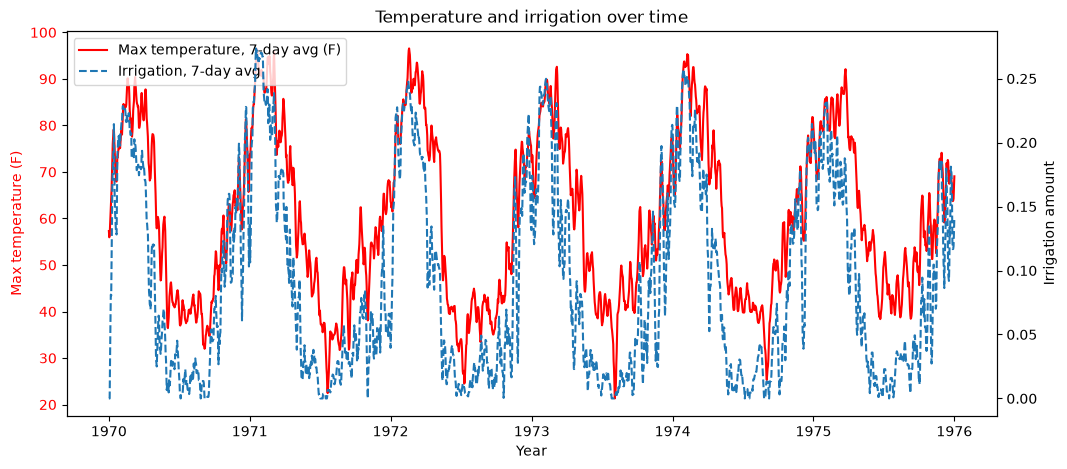

In [28]:
import matplotlib.dates as mdates

# Smooth both lines so the chart is easier to read
plot_df = df.sort_values("date").copy()

plot_df["max_temp_7day_avg_f"] = (
    plot_df["max_temp_f"]
    .rolling(window=7, min_periods=1)
    .mean()
)

plot_df["irrigation_7day_avg"] = (
    plot_df["irrigation_amount"]
    .rolling(window=7, min_periods=1)
    .mean()
)

fig, ax1 = plt.subplots(figsize=(12, 5))

# Temperature line
ax1.plot(
    plot_df["date"],
    plot_df["max_temp_7day_avg_f"],
    label="Max temperature, 7-day avg (F)",
    color="red",
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Max temperature (F)", color="red")
ax1.tick_params(axis="y", labelcolor="red")

# Show years on the x-axis
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Irrigation line on second y-axis
ax2 = ax1.twinx()

ax2.plot(
    plot_df["date"],
    plot_df["irrigation_7day_avg"],
    label="Irrigation, 7-day avg",
    linestyle="--",
)

ax2.set_ylabel("Irrigation amount")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
)

plt.title("Temperature and irrigation over time")
plt.show()

## 🎮 Step 5: Pick a clue and see if it relates to irrigation

Use the dropdown to choose one clue.

- A **good clue** (like `max_temp_f`) will show a visible pattern: as the dots go right, they tend to go up or down.
- A **junk clue** (like `dice_roll` or `barn_cat_naps`) will look like a random cloud of dots with no pattern at all.

Try a few of each and see the difference!

In [29]:
def scatter_feature(feature):
    plt.figure(figsize=(7, 5))
    plt.scatter(df[feature], df["irrigation_amount"], alpha=0.65)
    plt.xlabel(feature)
    plt.ylabel("irrigation_amount")
    plt.title(f"Does {feature} help predict irrigation?")
    plt.show()

feature_options = [c for c in ALL_FEATURES if c in df.columns]

if WIDGETS_AVAILABLE:
    widgets.interact(scatter_feature, feature=widgets.Dropdown(options=feature_options, value=feature_options[0]))
else:
    scatter_feature(feature_options[0])

interactive(children=(Dropdown(description='feature', options=('max_temp_f', 'mean_temp_f', 'mean_humidity_pct…

## 🧪 Step 6: The clues the model can choose from

The model can only learn from the clues (columns) we give it. **Garbage in, garbage out!**

To start, our first models will *only* be allowed to use the **junk clues**. That means they will do a bad job on purpose. 😅

Your mission later will be to swap in the **good clues** and beat the bad models.

The good clues to try:

```text
max_temp_f
mean_humidity_pct
avg_wind_mph
precip_in
temp_3day_avg_f
```

In [32]:
# We already defined the clue lists back in Step 2. Here is a reminder of
# what the model can pick from. (DEFAULT_FEATURES starts as the junk clues!)

print("✅ GOOD clues (helpful):")
for f in GOOD_FEATURES:
    print("   -", f)

print("\n❌ JUNK clues (useless):")
for f in JUNK_FEATURES:
    print("   -", f)

print("\n👉 The first models will start with:", DEFAULT_FEATURES)

Features available:
 - max_temp_f
 - min_temp_f
 - mean_temp_f
 - mean_humidity_pct
 - precip_in
 - avg_wind_mph
 - max_wind_mph
 - temp_3day_avg_f
 - temp_5day_avg_f
 - precip_3day_sum_in
 - precip_5day_sum_in
 - wind_3day_avg_mph
 - previous_irrigation_amount
 - days_since_irrigation
 - day_of_year
 - month


## 📏 Step 7: Split the data into practice and test days

We train on some days and test on different days.

This is like studying with practice questions, then taking a quiz on questions you have not seen before.

In [31]:
def make_train_test(feature_cols, test_size=0.25):
    clean = df[["date", "irrigation_amount"] + feature_cols].dropna().copy()
    X = clean[feature_cols]
    y = clean["irrigation_amount"]

    X_train, X_test, y_train, y_test, date_train, date_test = train_test_split(
        X, y, clean["date"], test_size=test_size, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return clean, X_train, X_test, y_train, y_test, date_train, date_test, scaler, X_train_scaled, X_test_scaled

print("✅ Helper function ready.")

✅ Helper function ready.


# 🤖 Model 1: Linear Regression

Linear regression learns a simple formula.

It is like saying:

```text
irrigation = a little bit of temperature + a little bit of wind - a little bit of rain + ...
```

It is simple, fast, and surprisingly useful.

### 👀 Watch the score on the first run

The cell below trains a model using only the **junk clues** (lucky number, dice roll, barn cat naps...). 

Look at two numbers when it finishes:

- **Mean absolute error (MAE)**: how far off the guesses are. *Lower is better.*
- **R² score**: how much of the pattern the model captured. *Closer to 1.0 is better. Near 0 (or negative) means the model is basically guessing.*

With junk clues, expect a **bad** R² (close to 0). That is the point! 🎯

✅ Linear Regression trained!
Mean absolute error: 0.030
R² score: 0.796

Mean absolute error means: on average, how far away was the model's guess?


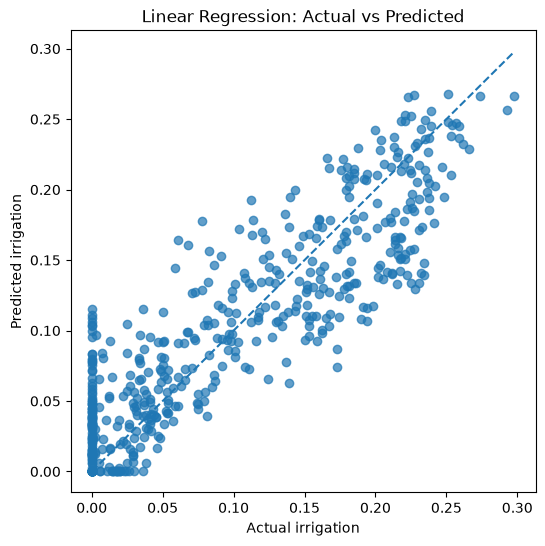

,date,actual_irrigation,predicted_irrigation,error
318,2020-06-27,0.216,0.158874,-0.057126
455,2020-07-04,0.210,0.155906,-0.054094
416,2020-07-07,0.172,0.137771,-0.034229
485,2020-07-09,0.208,0.141842,-0.066158
11,2020-07-13,0.211,0.176892,-0.034108


In [33]:
def train_linear_regression(feature_cols):
    clean, X_train, X_test, y_train, y_test, date_train, date_test, scaler, X_train_scaled, X_test_scaled = make_train_test(feature_cols)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)
    pred = np.clip(pred, 0, None)

    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results = pd.DataFrame({
        "date": date_test.values,
        "actual_irrigation": y_test.values,
        "predicted_irrigation": pred,
        "error": pred - y_test.values,
    }).sort_values("date")

    print("✅ Linear Regression trained!")
    print(f"Mean absolute error: {mae:.3f}")
    print(f"R² score: {r2:.3f}")
    print("\nMean absolute error means: on average, how far away was the model's guess?")

    plt.figure(figsize=(6, 6))
    plt.scatter(results["actual_irrigation"], results["predicted_irrigation"], alpha=0.7)
    max_val = max(results["actual_irrigation"].max(), results["predicted_irrigation"].max())
    plt.plot([0, max_val], [0, max_val], linestyle="--")
    plt.xlabel("Actual irrigation")
    plt.ylabel("Predicted irrigation")
    plt.title("Linear Regression: Actual vs Predicted")
    plt.show()

    return model, scaler, results, feature_cols

linear_model, linear_scaler, linear_results, linear_features = train_linear_regression(DEFAULT_FEATURES)
linear_results.head()

## 🎛️ Your turn: beat the junk model! 🏆

The boxes below start with the **junk clues** selected. Your job is to do better.

1. **Unselect** the junk clues (lucky_number, dice_roll, etc.).
2. **Select** the good clues (max_temp_f, mean_humidity_pct, avg_wind_mph, precip_in, temp_3day_avg_f).
3. Click **Train linear model** and watch the R² score jump up! 📈

(Tip: hold Ctrl/Cmd or Shift to select more than one clue.)

Things to experiment with:

- Use only `max_temp_f`. How good is one good clue?
- Use all 5 good clues. Better?
- Mix in a junk clue. Does it hurt?

**Question:** does adding *more* clues always help, or do bad clues drag the model down?

In [ ]:
if WIDGETS_AVAILABLE:
    feature_picker = widgets.SelectMultiple(
        options=ALL_FEATURES,
        value=tuple(DEFAULT_FEATURES),
        description="Features",
        rows=min(12, len(ALL_FEATURES)),
        layout=widgets.Layout(width="420px")
    )
    button = widgets.Button(description="Train linear model", button_style="success")
    output = widgets.Output()

    def on_train_linear_clicked(_):
        with output:
            clear_output()
            chosen = list(feature_picker.value)
            if len(chosen) == 0:
                print("Pick at least one feature.")
                return
            global linear_model, linear_scaler, linear_results, linear_features
            linear_model, linear_scaler, linear_results, linear_features = train_linear_regression(chosen)
            display(linear_results.head(10))

    button.on_click(on_train_linear_clicked)
    display(feature_picker, button, output)
else:
    print("Widgets are not available. Edit DEFAULT_FEATURES in the earlier cell and rerun.")

SelectMultiple(description='Features', index=(7, 9, 5, 3), layout=Layout(width='420px'), options=('max_temp_f'…

Button(button_style='success', description='Train linear model', style=ButtonStyle())

Output()

# 🧠 Model 2: A Small Neural Network

A neural network is made of small units called neurons.

Each neuron looks at the inputs, does a tiny calculation, and passes information to the next layer.

For this activity, we will use a very small neural network so it trains quickly.

You can change:

- Number of neurons
- Number of training rounds, called epochs
- Which clues the model sees

### 👀 Same trick as before

The first run below *also* starts with only the **junk clues**, so even a fancy neural network will do badly.

**Big idea:** a smarter model cannot fix bad clues. Good clues matter more than a fancy model!

✅ Neural network trained!
Hidden neurons: 8
Epochs: 30
Mean absolute error: 0.026
R² score: 0.835


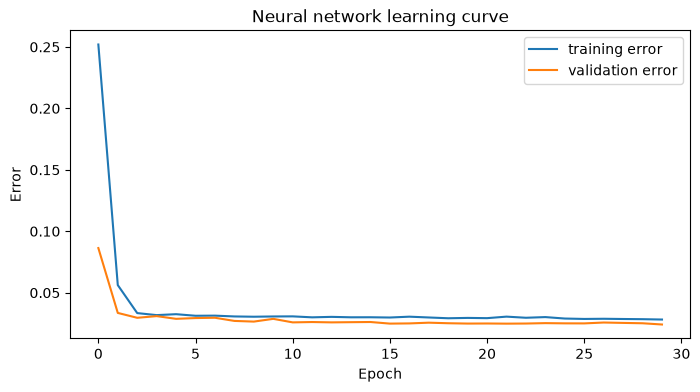

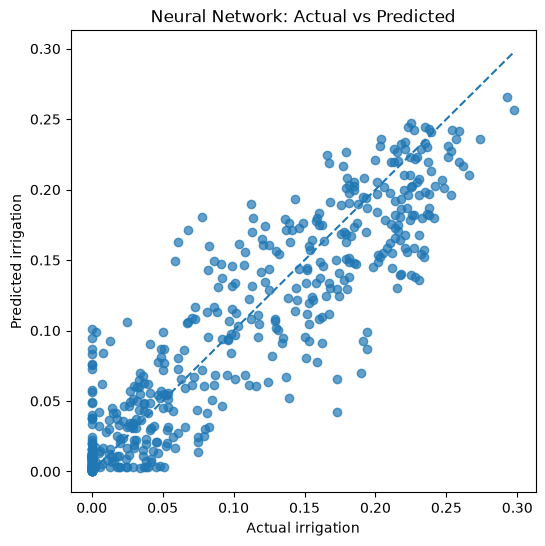

,date,actual_irrigation,predicted_irrigation,error
318,2020-06-27,0.216,0.174652,-0.041348
455,2020-07-04,0.210,0.162158,-0.047842
416,2020-07-07,0.172,0.150060,-0.021940
485,2020-07-09,0.208,0.158601,-0.049399
11,2020-07-13,0.211,0.175430,-0.035570


In [36]:
def train_neural_network(feature_cols, hidden_neurons=8, epochs=80, learning_rate=0.01):
    clean, X_train, X_test, y_train, y_test, date_train, date_test, scaler, X_train_scaled, X_test_scaled = make_train_test(feature_cols)

    if not TF_AVAILABLE:
        print("⚠️ TensorFlow is not installed in this environment.")
        print("Install tensorflow or run this notebook in Binder/Colab with tensorflow available.")
        return None, scaler, None, feature_cols

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(len(feature_cols),)),
        tf.keras.layers.Dense(hidden_neurons, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mean_absolute_error",
        metrics=["mean_absolute_error"]
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        verbose=0
    )

    pred = model.predict(X_test_scaled, verbose=0).reshape(-1)
    pred = np.clip(pred, 0, None)

    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results = pd.DataFrame({
        "date": date_test.values,
        "actual_irrigation": y_test.values,
        "predicted_irrigation": pred,
        "error": pred - y_test.values,
    }).sort_values("date")

    print("✅ Neural network trained!")
    print(f"Hidden neurons: {hidden_neurons}")
    print(f"Epochs: {epochs}")
    print(f"Mean absolute error: {mae:.3f}")
    print(f"R² score: {r2:.3f}")

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="training error")
    plt.plot(history.history["val_loss"], label="validation error")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.title("Neural network learning curve")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.scatter(results["actual_irrigation"], results["predicted_irrigation"], alpha=0.7)
    max_val = max(results["actual_irrigation"].max(), results["predicted_irrigation"].max())
    plt.plot([0, max_val], [0, max_val], linestyle="--")
    plt.xlabel("Actual irrigation")
    plt.ylabel("Predicted irrigation")
    plt.title("Neural Network: Actual vs Predicted")
    plt.show()

    return model, scaler, results, feature_cols

nn_model, nn_scaler, nn_results, nn_features = train_neural_network(DEFAULT_FEATURES, hidden_neurons=8, epochs=30, learning_rate=0.01)
if nn_results is not None:
    display(nn_results.head())

## 🎛️ Your turn: train a better neural network! 🏆

Just like before, the boxes start with the **junk clues**. Swap in the **good clues** and watch the model improve.

Questions to explore:

- Swap junk clues for good clues. How much does the R² improve?
- With good clues, what happens with only 2 neurons? With 32 neurons?
- What happens with 10 epochs? With 200 epochs?
- Does the neural network always beat linear regression?
- Even with lots of neurons and epochs, can the model do well using *only* junk clues?

In [37]:
if WIDGETS_AVAILABLE:
    nn_feature_picker = widgets.SelectMultiple(
        options=ALL_FEATURES,
        value=tuple(DEFAULT_FEATURES),
        description="Features",
        rows=min(12, len(ALL_FEATURES)),
        layout=widgets.Layout(width="420px")
    )
    neurons_slider = widgets.IntSlider(value=8, min=2, max=32, step=2, description="Neurons")
    epochs_slider = widgets.IntSlider(value=80, min=10, max=250, step=10, description="Epochs")
    lr_slider = widgets.FloatLogSlider(value=0.01, base=10, min=-4, max=-1, step=0.25, description="Learn rate")
    nn_button = widgets.Button(description="Train neural net", button_style="warning")
    nn_output = widgets.Output()

    def on_train_nn_clicked(_):
        with nn_output:
            clear_output()
            chosen = list(nn_feature_picker.value)
            if len(chosen) == 0:
                print("Pick at least one feature.")
                return
            global nn_model, nn_scaler, nn_results, nn_features
            nn_model, nn_scaler, nn_results, nn_features = train_neural_network(
                chosen,
                hidden_neurons=neurons_slider.value,
                epochs=epochs_slider.value,
                learning_rate=lr_slider.value,
            )
            if nn_results is not None:
                display(nn_results.head(10))

    nn_button.on_click(on_train_nn_clicked)
    display(nn_feature_picker, neurons_slider, epochs_slider, lr_slider, nn_button, nn_output)
else:
    print("Widgets are not available. Edit the numbers in the earlier cell and rerun.")

SelectMultiple(description='Features', index=(7, 9, 5, 3), layout=Layout(width='420px'), options=('max_temp_f'…

IntSlider(value=8, description='Neurons', max=32, min=2, step=2)

IntSlider(value=80, description='Epochs', max=250, min=10, step=10)

FloatLogSlider(value=0.01, description='Learn rate', max=-1.0, min=-4.0, step=0.25)

Button(button_style='warning', description='Train neural net', style=ButtonStyle())

Output()

# 🏁 Final Challenge: Predict Today's Irrigation

Now the fun part.

Use today's field/weather values and ask the model:

> How much irrigation do you think happened today?

After the farmer tells us the real value, we can compare.

In [38]:
def build_today_row(
    max_temp_f=85,
    mean_humidity_pct=40,
    avg_wind_mph=8,
    precip_in=0.0,
):
    # Start from the most recent real day so every column already has a value.
    # (This includes the junk columns, in case the model was trained on them.)
    latest = df.iloc[-1].copy()

    # Override just the good weather clues with today's slider values.
    latest["max_temp_f"] = max_temp_f
    latest["mean_humidity_pct"] = mean_humidity_pct
    latest["avg_wind_mph"] = avg_wind_mph
    latest["precip_in"] = precip_in

    # The 3-day average temperature is close to today's temperature.
    latest["temp_3day_avg_f"] = max_temp_f - 10

    return latest


def predict_today(model_name="Linear Regression", max_temp_f=85, mean_humidity_pct=40, avg_wind_mph=8, precip_in=0.0):
    if model_name == "Linear Regression":
        model = linear_model
        scaler = linear_scaler
        features = linear_features
    else:
        model = nn_model
        scaler = nn_scaler
        features = nn_features
        if model is None:
            print("Train the neural network first, or use Linear Regression.")
            return

    today = build_today_row(
        max_temp_f=max_temp_f,
        mean_humidity_pct=mean_humidity_pct,
        avg_wind_mph=avg_wind_mph,
        precip_in=precip_in,
    )

    X_today = pd.DataFrame([today[features].to_dict()])
    X_today_scaled = scaler.transform(X_today)

    if model_name == "Linear Regression":
        pred = model.predict(X_today_scaled)[0]
    else:
        pred = model.predict(X_today_scaled, verbose=0).reshape(-1)[0]

    pred = max(float(pred), 0)

    print("🌾 Today's irrigation prediction")
    print("------------------------------")
    print(f"Model: {model_name}")
    print(f"Clues this model uses: {features}")
    print(f"Predicted irrigation amount: {pred:.3f}")
    if any(f in JUNK_FEATURES for f in features):
        print("\n⚠️ This model was trained on some JUNK clues, so don't trust this guess!")
    print("\nRemember: this is a learning model, not farm advice!")

if WIDGETS_AVAILABLE:
    model_dropdown = widgets.Dropdown(options=["Linear Regression", "Neural Network"], value="Linear Regression", description="Model")
    widgets.interact(
        predict_today,
        model_name=model_dropdown,
        max_temp_f=widgets.FloatSlider(value=85, min=50, max=110, step=1, description="Max temp F"),
        mean_humidity_pct=widgets.FloatSlider(value=40, min=10, max=100, step=1, description="Humidity %"),
        avg_wind_mph=widgets.FloatSlider(value=8, min=0, max=30, step=1, description="Wind mph"),
        precip_in=widgets.FloatSlider(value=0.0, min=0, max=1.5, step=0.01, description="Rain in"),
    )
else:
    predict_today()

interactive(children=(Dropdown(description='Model', options=('Linear Regression', 'Neural Network'), value='Li…

## 📝 Reflection Questions

Discuss with your group:

1. How bad was the very first model (the one using junk clues)? What was its R²?
2. How much better did your model get once you used the good clues?
3. Which single clue seemed most helpful?
4. Did adding junk clues ever make a model *worse*?
5. Did the neural network beat linear regression? Could a fancy model fix bad clues?
6. What information might the farmer use that our model cannot see?

**The big takeaway:** good clues (features) matter more than a fancy model. Choosing the right data is one of the most important jobs in machine learning! 🌾

Possible answers:

- Soil moisture
- Crop type
- Crop growth stage
- Water cost
- Equipment problems
- Farmer experience
- Weather forecast, not just past weather

## ⚠️ Important

This notebook is for learning.

Real irrigation decisions should be made by farmers, agronomists, irrigation specialists, and appropriate farm systems.

Machine learning can help us ask better questions, but it does not replace real-world expertise.